# AMS563 Homework 3 (Spring 2026) - Part 3

This assignment is for AMS563, Spring 2026. Complete all tasks in this notebook. Keep the structure unchanged and run all cells before submission.


## Code
---


In [ ]:
HW3_ROOT_PATH = '/gdrive/MyDrive/AMS563/AMS563-25S-HW3/'
PATH_TO_PART3 = HW3_ROOT_PATH + 'part3/'
PATH_TO_COCO = HW3_ROOT_PATH + 'coco/'


You will be using this code [unet.zip](https://drive.google.com/file/d/1p2tMMUfF2vfcr3QHipJx0XyiBOMWoMNM/view?usp=sharing) to complete your work. This code contains all the tools for loading dataset, training the newtorks, loss methods and evaluation metrics.

To pull this code into your drive, you have to first add the zip file as shortcut to current working directory (PATH_TO_PART3 above). To do this, open the above link and click on "Add shortcut to Drive" button (drive symbol with a plus) and navigate to working PATH_TO_PART3 directory and add shortcut.

We will use the same dataset that you have used in the Part 2 : [coco.zip dataset](https://drive.google.com/file/d/1GVyxYHwVgiG9z_Sn46wslT_2n65DLZRw/view?usp=sharing). Put this in the root of your hw3 HW3_ROOT_PATH. If you have this extracted to some path you can re-use the it.


In [ ]:
from google.colab import drive
drive.mount('/gdrive')
# CD into root of your homework2 part3 directory
%cd -q $HW3_ROOT_PATH
!mkdir -p '{PATH_TO_PART3}'
%cd $PATH_TO_PART3

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).
/gdrive/MyDrive/AMS563/AMS563-25S-HW3/part3


In [ ]:
!ls

unet


In [ ]:
!pip install -U 'git+https://github.com/cocodataset/cocoapi.git#subdirectory=PythonAPI'

  Cloning https://github.com/cocodataset/cocoapi.git to /tmp/pip-req-build-9novn38a
  Running command git clone --filter=blob:none --quiet https://github.com/cocodataset/cocoapi.git /tmp/pip-req-build-9novn38a
  Resolved https://github.com/cocodataset/cocoapi.git to commit 8c9bcc3cf640524c4c20a9c40e89cb6a2f2fa0e9
  Preparing metadata (setup.py) ... done


In [ ]:
!unzip -n ../coco.zip -d ..
!unzip -n unet.zip

unzip:  cannot find or open ../coco.zip, ../coco.zip.zip or ../coco.zip.ZIP.
unzip:  cannot find or open unet.zip, unet.zip.zip or unet.zip.ZIP.


In [ ]:
%cd -q unet
!ls

coco.py  images  main.py  __pycache__  transforms.py  unet.py  util


### Load helper method

In [ ]:
import matplotlib.pyplot as plt
import os
import numpy as np

def show_images(folder_path):
    image_paths = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
    image_paths = image_paths[:50]
    rows = 5
    cols = 10
    fig, axes = plt.subplots(rows, cols, figsize=(15, 8))
    for i, image_path in enumerate(image_paths):
        image = plt.imread(image_path)
        row = int(i / cols)
        col = i % cols
        axes[row, col].imshow(image)
        axes[row, col].set_title(os.path.basename(image_path))
        axes[row, col].axis('off')
    plt.tight_layout()
    plt.show()

## Training
---
You will use main.py for training, evaluating and visualizing.



In [ ]:
!python main.py --help

device cuda
usage: main.py [-h] [--coco_path COCO_PATH] [--batch_size BATCH_SIZE]
               [--epochs EPOCHS] [--eval] [--load_pretrained]
               [--skip {concat,sum}] [--checkpoint CHECKPOINT]

Train a segmentation model on COCO data.

options:
  -h, --help            show this help message and exit
  --coco_path COCO_PATH
                        Path to COCO dataset directory.
  --batch_size BATCH_SIZE
                        Batch size for training.
  --epochs EPOCHS       Epochs for training.
  --eval                Whether to evaluate the model on the validation set.
  --load_pretrained     Whether to evaluate the model on the validation set.
  --skip {concat,sum}   Skip connection strategy: either concatenation
                        (concat) or summation (sum).
  --checkpoint CHECKPOINT
                        Path to checkpoint file.


## Implement UNet (20 points)
---

`unet.py` contains two classes `UNet()` and `SumUNet()`, both are implementations of `torch.nn.Module()`.

You need to complete the methods `UNet:__init__()` and `UNet:forward()` to implement a segmentation architecture that processes input of shape `N x 3 x H x W` (N is batch size) and will output a mask of shape `N x 1 x H x W`

###Requirements
1. Encoder part of the UNet will be made of pytorch Resnet's layers 1 to 4.

    https://pytorch.org/vision/main/_modules/torchvision/models/resnet.html

    Essentially, your UNet's encoder will be using `torchvision.models.resnet`'s `layer1, layer2, layer3, layer4` for downsampling.

2. When argument `load_pretrained_encoder_layers` of __init__() is set to true, the layers will be initialized with the pretrained weights. You can use the default pre-trained weights provided by pytorch.

3. As described in the paper or above repo, `concatenation` operations will be done for the skip connections. (in the upcoming section, you will instead use summation)

Note:
- You are recommended to size your model under 25M paramenters. As more parameters will hurt the trainig time and even effeciency.
- For the decoder section (later half), you will not be able to use any pre-trained weights, so you will use randomly initialized blocks (that you will design on your own). Each block usually have layers of `[Conv, BatchNorm, ReLu]`
- You need not use any ReLU on the last mask output layer.

Hint:
- chose a [resnet](https://pytorch.org/vision/main/_modules/torchvision/models/resnet.html) size
- understand the `In` channels & `Out` channels of each layer of your chosen resnet()
- build decoder layers so that they will work along the above 4 layers
- conclude how to use the skip connections. ( you will using `concatenation`).
- complete the forward() method
- use print(x.shape) statements to understand the flow of tensors

Log reference: [log](https://drive.google.com/file/d/1ZGd-ciOKkajri0GEOwc-uJDBjGJHJdNY/view?usp=drive_link)

Aim for mIoU more than 0.35. You may not be penalized for low perfromance of your model.  



In [ ]:
!python main.py --skip concat --coco_path "{PATH_TO_COCO}" --batch_size 30

device cuda
Namespace(coco_path='/gdrive/MyDrive/AMS563/AMS563-25S-HW3/coco/', batch_size=30, epochs=20, eval=False, load_pretrained=False, skip='concat', checkpoint='concat_checkpoint.pth')
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Epoch: [0]  [ 0/16]  eta: 0:04:09    time: 15.6216  data: 14.1915  max mem: 3406
Epoch: [0]  [10/16]  eta: 0:01:07    time: 11.2517  data: 10.9774  max mem: 3434
Epoch: [0]  [15/16]  eta: 0:00:10    time: 10.9510  data: 10.7122  max mem: 3434
Epoch: [0] Total time: 0:02:55 (10.9513 s / it)
train: dice: 0.769692, bce: 0.731801, loss: 0.744305
LR 0.0005
Epoch: [0]  [0/2]  eta: 0:00:20    time: 10.1479  data: 9.9396  max mem: 3434
Epoch: [0]  [1/2]  eta: 0:00:08    time: 8.5556  data: 8.3942  max mem: 3434
Epoch: [0] Total time: 0:00:17 (8.5562 s / it)
val: dice: 0.795228, bce: 0.684129, loss: 0.720792, mIoU: 0.195118, mDice: 0.298570
sav

### Evaluation
To just run the evaluation or to produce the predicted masks in the `images/` folder, you need to run the main.py with --eval.
Note that this will load the latest stored checkpoint corresponding to the --skip flag that you have provided.

In [ ]:
!python main.py --skip concat --coco_path "{PATH_TO_COCO}" --eval

device cuda
Namespace(coco_path='/gdrive/MyDrive/AMS563/AMS563-25S-HW3/coco/', batch_size=20, epochs=20, eval=True, load_pretrained=False, skip='concat', checkpoint='concat_checkpoint.pth')
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Performance on validation dataset: mIoU:0.37788113951683044 , mDice:0.49844464659690857


### With --load_pretrained

When properly configured using pre-trained weights should result in higher mIoUs. You can expect mIoU around .65  

In [ ]:
!python main.py --skip concat --coco_path "{PATH_TO_COCO}"  --load_pretrained --batch_size 30

device cuda
Namespace(coco_path='/gdrive/MyDrive/AMS563/AMS563-25S-HW3/coco/', batch_size=30, epochs=20, eval=False, load_pretrained=True, skip='concat', checkpoint='concat_checkpoint.pth')
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Epoch: [0]  [ 0/16]  eta: 0:00:22    time: 1.4161  data: 0.7570  max mem: 3406
Epoch: [0]  [10/16]  eta: 0:00:06    time: 1.0447  data: 0.8693  max mem: 3434
Epoch: [0]  [15/16]  eta: 0:00:00    time: 0.9976  data: 0.8377  max mem: 3434
Epoch: [0] Total time: 0:00:15 (0.9977 s / it)
train: dice: 0.718319, bce: 0.628042, loss: 0.657833
LR 0.0005
Epoch: [0]  [0/2]  eta: 0:00:01    time: 0.5565  data: 0.4190  max mem: 3434
Epoch: [0]  [1/2]  eta: 0:00:00    time: 0.4529  data: 0.3440  max mem: 3434
Epoch: [0] Total time: 0:00:00 (0.4534 s / it)
val: dice: 0.754062, bce: 0.619135, loss: 0.663661, mIoU: 0.519279, mDice: 0.627584
saving best 

In [ ]:
!python main.py --skip concat --coco_path "{PATH_TO_COCO}" --eval --batch_size 30

device cuda
Namespace(coco_path='/gdrive/MyDrive/AMS563/AMS563-25S-HW3/coco/', batch_size=30, epochs=20, eval=True, load_pretrained=False, skip='concat', checkpoint='concat_checkpoint.pth')
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Performance on validation dataset: mIoU:0.6280901432037354 , mDice:0.7200362682342529


Let us see the masks generated by the best run:
It is okay if the masks are not perfectly aligned. We are only training over 500 images for a short duration!

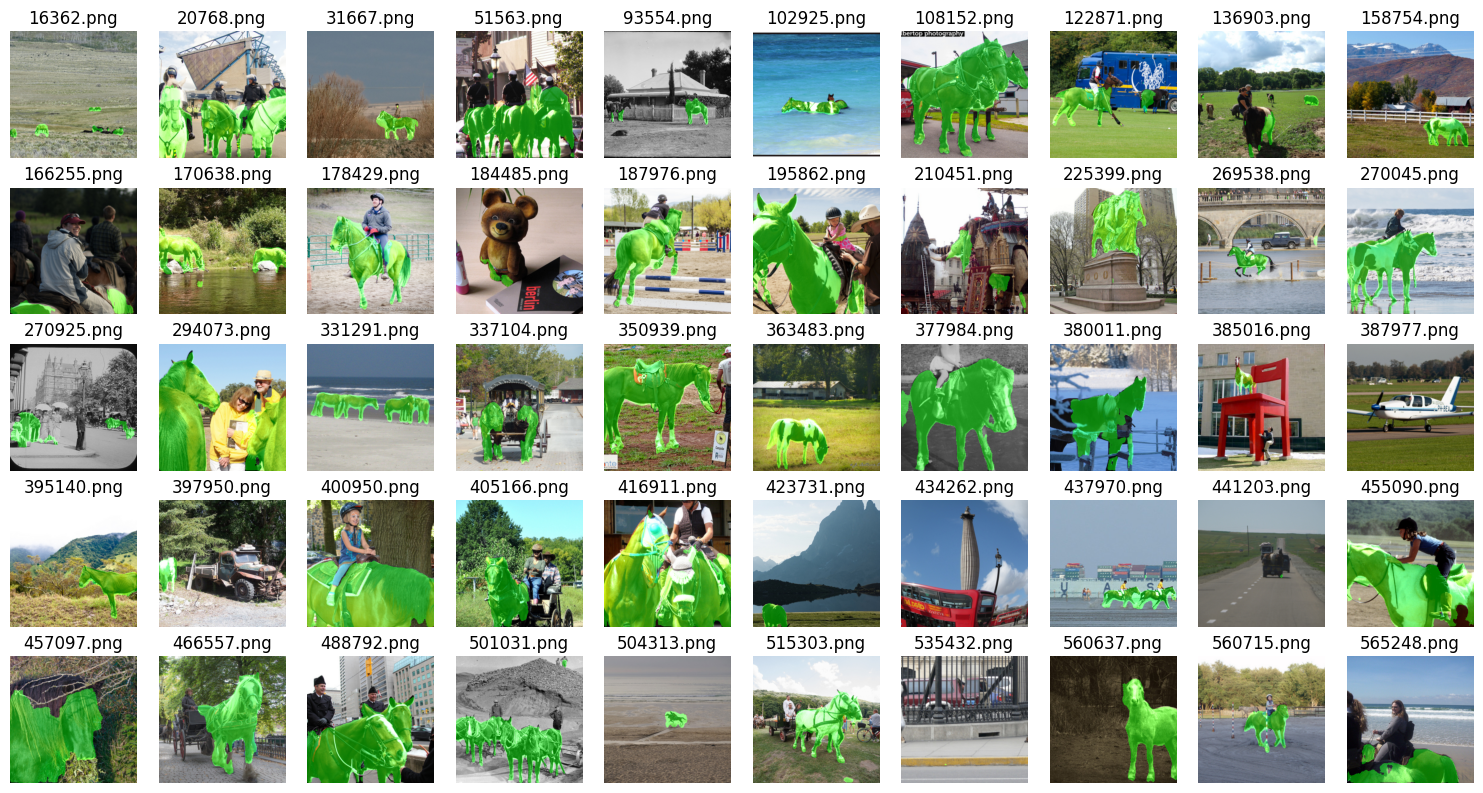

In [ ]:
folder_path = 'images'
show_images(folder_path)

## Implement SumUNet (15 points)
---
This is very much similar to above UNet, but for the skip connections we will be using summation operation instead of concatenation. This is kind of an open ended question, in the sense that there are multuple ways you can design connections.

Feel free to use any layers | blocks | up/down sampling.

Hint:
- Again you need to focus on the feature shapes
- you can use sampling techniques to change the height/width
- you can use conv layers to change number of channels  

Note: You can chose to remove --load_pretrained from the below cell if you think that will have a better perfromance


In [ ]:
!python main.py --skip sum --coco_path "{PATH_TO_COCO}"  --load_pretrained --batch_size 30

device cuda
Namespace(coco_path='/gdrive/MyDrive/AMS563/AMS563-25S-HW3/coco/', batch_size=30, epochs=20, eval=False, load_pretrained=True, skip='sum', checkpoint='sum_checkpoint.pth')
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Epoch: [0]  [ 0/16]  eta: 0:00:22    time: 1.3991  data: 0.7713  max mem: 3230
Epoch: [0]  [10/16]  eta: 0:00:05    time: 0.9156  data: 0.7513  max mem: 3249
Epoch: [0]  [15/16]  eta: 0:00:00    time: 0.9829  data: 0.8330  max mem: 3249
Epoch: [0] Total time: 0:00:15 (0.9830 s / it)
train: dice: 0.719030, bce: 0.622382, loss: 0.654276
LR 0.0005
Epoch: [0]  [0/2]  eta: 0:00:01    time: 0.5682  data: 0.4391  max mem: 3249
Epoch: [0]  [1/2]  eta: 0:00:00    time: 0.4455  data: 0.3477  max mem: 3249
Epoch: [0] Total time: 0:00:00 (0.4460 s / it)
val: dice: 0.721279, bce: 0.547863, loss: 0.605090, mIoU: 0.513231, mDice: 0.630225
saving best model 

In [ ]:
!python main.py --skip sum --coco_path "{PATH_TO_COCO}"  --eval

device cuda
Namespace(coco_path='/gdrive/MyDrive/AMS563/AMS563-25S-HW3/coco/', batch_size=20, epochs=20, eval=True, load_pretrained=False, skip='sum', checkpoint='sum_checkpoint.pth')
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Performance on validation dataset: mIoU:0.6093226671218872 , mDice:0.7079207301139832
